# What One Small Change Can Do — Simulating the Logistic Map




$$x_{t+1} = r \cdot x_t (1 - x_t)$$



This notebook is not a math lesson. It's a series of small experiments, all built from the exact same one-line rule. Each "Take" changes **one thing**, simulates, and shows you what happened.
No new theory needed to follow along -- just watch what varying one detail actually does.

**A note before we start:** this notebook isn't attached to a required reading -- it's a bridge I
built between Session 1 and Session 2, my own way of connecting the two.


First, the tools we'll need throughout: `numpy` for the math, `pandas` for a table or two, and
`matplotlib` for every plot.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



---
## The Toolbox — every function this notebook uses

Eight functions, defined once, right here, in the order the Takes below will need them. Every
"Take" from this point on does nothing but call one or two of these, build a small table, and plot
it -- no new function definitions hiding inside an experiment. Pseudocode sits next to the trickier
ones; the simpler ones just get a one-line explanation.


### **`logistic_step(x, r)`**

The whole rule, as a function. `x` is the number we feed in, `r` is a
dial we'll be turning throughout this notebook. This rule, $x_{t+1} = r \cdot x_t(1-x_t)$, is
called the **logistic map**. Every other function below is built on top of this one line.


In [2]:
def logistic_step(x, r):
    """Feed in x, get the next value back. r is just a dial we can turn."""
    return r * x * (1 - x)


### **`simulate(r, x0, n_steps)`**

Start at `x0`, and keep feeding each result back in as the next
input, `n_steps` times. This is what turns one application of the rule into a trajectory.


In [3]:
def simulate(r, x0, n_steps):
    """Start at x0, and keep feeding each result back in as the next input."""
    xs = [x0]
    for _ in range(n_steps - 1):
        xs.append(logistic_step(xs[-1], r))
    return np.array(xs)


### **`cobweb_path(r, x0, n_steps)`**

Traces the up/down-to-the-curve, across-to-the-diagonal
staircase a cobweb diagram is built from. Each step is really two moves: apply the rule (up/down to
the curve), then feed the result back in (across to the diagonal).


#### Pseudocode — `cobweb_path`

1. Start a staircase at `(x0, 0)`
2. Repeat `n_steps` times:
   1. Compute where the rule sends the current `x` (that's the next `y`)
   2. Add the "up/down to the curve" move: from `(x, x)` on the diagonal to `(x, y)` on the curve
   3. Add the "across to the diagonal" move: from `(x, y)` to `(y, y)`
   4. The new current point is `(y, y)` -- ready for the next step
3. Return the full list of staircase points, ready to plot


In [4]:
def cobweb_path(r, x0, n_steps):
    """Trace the up/down-to-the-curve, across-to-the-diagonal staircase that
    a cobweb diagram is built from."""
    x = x0                                            # (1)
    points_x, points_y = [x], [0]
    for _ in range(n_steps):                           # (2)
        y = logistic_step(x, r)                         # (2.1)
        points_x += [x, y]                              # (2.2)
        points_y += [y, y]
        x = y                                           # (2.4)
        points_x += [x]                                 # (2.3)
        points_y += [x]
    return points_x, points_y                           # (3)


### **`count_attractors(r, ...)`**

Estimates how many points the system is cycling through,
long-run, at a given `r`. Returns `None` if it looks chaotic instead of periodic.


#### Pseudocode — `count_attractors`

1. Run the rule forward many times without recording anything, so any transient settles out
2. From there, keep running and record each value, rounded to a few decimal places
3. Collect only the *distinct* rounded values seen -- that count is the number of points the
   system is cycling through
4. If that count grows past a small ceiling, stop and report "too many to count simply" --
   chaos, not a clean cycle
5. Otherwise, return how many distinct points were found


In [5]:
def count_attractors(r, x0=0.3, burn_in=3000, n_check=300, precision=2, max_period=16):
    """Estimate how many points the system is cycling through, long-run, at
    this r. Returns None if it looks chaotic instead of periodic."""
    x = x0
    for _ in range(burn_in):                            # (1)
        x = logistic_step(x, r)

    seen = []
    for _ in range(n_check):                             # (2)
        x = logistic_step(x, r)
        rounded = round(x, precision)
        if rounded not in seen:                           # (3)
            seen.append(rounded)
        if len(seen) > max_period:                         # (4)
            return None

    return len(seen)                                       # (5)


### **`cobweb_points_up_to(r, frame, x0)`**

Builds the cobweb staircase up to a requested frame, one
half-step (vertical or horizontal) at a time. This is what lets the interactive slider later redraw
a single frame live, instead of pre-rendering a whole animation up front.


#### Pseudocode — `cobweb_points_up_to`

1. Start at `x0`
2. Each iteration takes **two** frames, not one -- so we can watch the vertical move (to the
   curve) and the horizontal move (to the diagonal) happen separately, rather than both at once
3. Walk forward frame by frame, up to whichever frame we've been asked for:
   1. On an even frame: add the vertical move -- from the diagonal up/down to the curve
   2. On an odd frame: add the horizontal move -- from the curve across to the diagonal, and
      that's one full iteration completed
4. Return every point built so far, the current `x`, and how many full iterations have completed


In [6]:
def cobweb_points_up_to(r, frame, x0=0.3):
    """Build the cobweb staircase up to a requested frame, where each
    iteration is split into two frames: a vertical move, then a horizontal one."""
    x = x0                                                    # (1)
    points = [(x0, 0)]
    completed_iterations = 0

    for current_frame in range(frame):                         # (3)
        next_x = logistic_step(x, r)
        if current_frame % 2 == 0:                              # (3.1) vertical: up/down to the curve
            points.append((x, next_x))
        else:                                                    # (3.2) horizontal: across to the diagonal
            points.append((next_x, next_x))
            x = next_x
            completed_iterations += 1

    return np.array(points), x, completed_iterations             # (4)


### **`sweep(r_min, r_max, n_r, ...)`**

Runs many `r` values *simultaneously*, as arrays, rather than
one at a time. First lets every trajectory settle (throwing the early steps away), then records
what each one actually settles onto.


In [7]:
def sweep(r_min, r_max, n_r, n_settle=300, n_record=150, x0=0.2):
    """Run the same simulate-and-throw-away-the-start idea, for many r values
    at once, and record only where each one ends up long-run."""
    r_values = np.linspace(r_min, r_max, n_r)
    x = np.full(n_r, x0)

    for _ in range(n_settle):          # let each r's trajectory settle first
        x = logistic_step(x, r_values)

    all_r, all_x = [], []
    for _ in range(n_record):          # now record where it actually lands
        x = logistic_step(x, r_values)
        all_r.append(r_values)
        all_x.append(x)

    return np.concatenate(all_r), np.concatenate(all_x)


### **`two_starts(r, x0, epsilon, n_steps)`**

Runs `simulate` twice, from two almost-identical
starting points, so we can compare them directly.


In [8]:
def two_starts(r, x0, epsilon, n_steps):
    """Run the simulation twice, from two almost-identical starting points."""
    x1 = simulate(r, x0, n_steps)
    x2 = simulate(r, x0 + epsilon, n_steps)
    return x1, x2


### **`divergence_speed(r, ...)`**

Tracks, at every step, how strongly the rule stretches or shrinks
a tiny difference (its slope), and averages that over many steps, after first letting the
trajectory settle.


In [9]:
def divergence_speed(r, x0=0.4, burn_in=200, n_steps=2000):
    """On average, does a tiny error grow or shrink at each step? One number
    answers this -- computed straight from the rule's own slope."""
    x = x0
    for _ in range(burn_in):
        x = logistic_step(x, r)

    total = 0.0
    for _ in range(n_steps):
        slope_here = abs(r * (1 - 2*x))
        total += np.log(slope_here + 1e-16)
        x = logistic_step(x, r)

    return total / n_steps


That's the whole toolbox -- eight functions, nothing else. From here on, every Take is just: call
one of these, look at the table, look at the picture.


---
# **Take 1 — The rule, doing nothing interesting yet**

Before we simulate anything, let's just look at what we're working with: one rule, applied once.
Give it a number between 0 and 1, it gives you another number between 0 and 1 back.


Let's use it: plug in ten evenly-spaced `x` values, all at one fixed setting of `r`, and put the
input and output side by side in a table.


In [10]:
r = 0.8
x_values = np.linspace(0, 1, 10)

table = pd.DataFrame({"x_t": x_values, "x_next": logistic_step(x_values, r)})
table


,x_t,x_next
0,0.000000,0.000000
1,0.111111,0.079012
2,0.222222,0.138272
3,0.333333,0.177778
4,0.444444,0.197531
5,0.555556,0.197531
6,0.666667,0.177778
7,0.777778,0.138272
8,0.888889,0.079012
9,1.000000,0.000000


Ten rows, ten pairs of numbers -- notice the output isn't a simple multiple of the input; it rises
then falls back toward zero as `x_t` approaches 1. Let's see that same relationship as a smooth
curve instead of a table, using many more points.


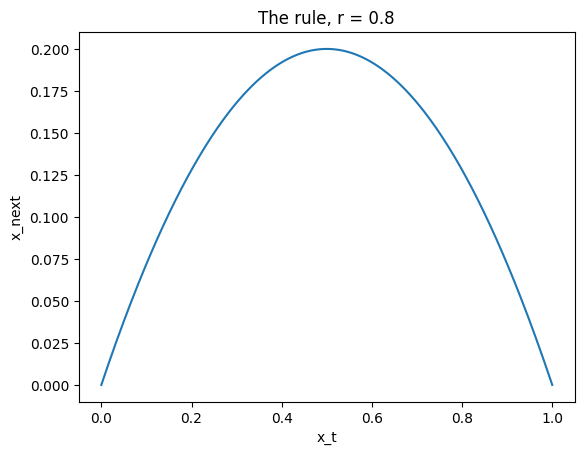

In [11]:
x_grid = np.linspace(0, 1, 300)

plt.figure()
plt.plot(x_grid, logistic_step(x_grid, r))
plt.title(f"The rule, r = {r}")
plt.xlabel("x_t"); plt.ylabel("x_next")
plt.show()


A table, and a smooth curve, nothing surprising here we have a parabole:

> We are plotting f(x) = r·x(1−x), which is a downward-opening parabola: roots at x = 0 and x = 1, vertex at (0.5, r/4)

One input, one output, every time, no ambiguity. This is our baseline.

Every Take from here on reuses `logistic_step`, unchanged. Only *how we use it* will change, one detail at a time.


---
# **Take 2 — Feeding the output back in**

Same rule as before, but now we use its own output as the next input, and repeat.

We'll try it from one starting point, using the same `r = 2.5` and the same number of steps, and see where it ends up.

Before the picture, here's the table behind it — same `x_t` / `x_next` columns as Take 1, but now chained across steps instead of just one row.

In [12]:
r = 2.5
x0_take2 = 0.05
n_steps_take2 = 25

x_t = simulate(r, x0_take2, n_steps=n_steps_take2)
x_next = logistic_step(x_t, r)

table_take2 = pd.DataFrame({"x_t": x_t, "x_next": x_next})
table_take2.index.name = "step"
table_take2

,x_t,x_next
step,,
0,0.050000,0.118750
1,0.118750,0.261621
2,0.261621,0.482939
3,0.482939,0.624272
4,0.624272,0.586391
5,0.586391,0.606341
6,0.606341,0.596729
7,0.596729,0.601609
8,0.601609,0.599189


In [13]:
r = 2.5
starts_take2 = [0.05, 0.3, 0.7, 0.95]
n_steps_take2 = 25

cols = {}
for x0 in starts_take2:
    x_t = simulate(r, x0, n_steps=n_steps_take2)
    x_next = logistic_step(x_t, r)
    cols[(f"start={x0}", "x_t")] = x_t
    cols[(f"start={x0}", "x_next")] = x_next

table_take2 = pd.DataFrame(cols)
table_take2.columns = pd.MultiIndex.from_tuples(table_take2.columns, names=["start", ""])
table_take2.index.name = "step"
table_take2


start start=0.05           start=0.3           start=0.7           start=0.95  \
             x_t    x_next       x_t    x_next       x_t    x_next        x_t   
step                                                                            
0       0.050000  0.118750  0.300000  0.525000  0.700000  0.525000   0.950000   
1       0.118750  0.261621  0.525000  0.623437  0.525000  0.623438   0.118750   
2       0.261621  0.482939  0.623437  0.586908  0.623438  0.586908   0.261621   
3       0.482939  0.624272  0.586908  0.606118  0.586908  0.606118   0.482939   
4       0.624272  0.586391  0.606118  0.596848  0.606118  0.596848   0.624272   
5       0.586391  0.606341  0.596848  0.601551  0.596848  0.601551   0.586391   
6       0.606341  0.596729  0.601551  0.599218  0.601551  0.599218   0.606341   
7       0.596729  0.601609  0.599218  0.600389  0.599218  0.600389   0.596729   
8       0.601609  0.599189  0.600389  0.599805  0.600389  0.599805   0.601609   
9       0.599189  0.600404  0.599805  0.600097  0.599805  0.600097   0.599189   
10      0.600404  0.599798  0.600097  0.599951  0.600097  0.599951   0.600404   
11      0.599798  0.600101  0.599951  0.600024  0.599951  0.600024   0.599798   
12      0.600101  0.599949  0.600024  0.599988  0.600024  0.599988   0.600101   
13      0.599949  0.600025  0.599988  0.600006  0.599988  0.600006   0.599949   
14      0.600025  0.599987  0.600006  0.599997  0.600006  0.599997   0.600025   
15      0.599987  0.600006  0.599997  0.600002  0.599997  0.600002   0.599987   
16      0.600006  0.599997  0.600002  0.599999  0.600002  0.599999   0.600006   
17      0.599997  0.600002  0.599999  0.600000  0.599999  0.600000   0.599997   
18      0.600002  0.599999  0.600000  0.600000  0.600000  0.600000   0.600002   
19      0.599999  0.600000  0.600000  0.600000  0.600000  0.600000   0.599999   
20      0.600000  0.600000  0.600000  0.600000  0.600000  0.600000   0.600000   
21      0.600000  0.600000  0.600000  0.600000  0.600000  0.600000   0.600000   
22      0.600000  0.600000  0.600000  0.600000  0.600000  0.600000   0.600000   
23      0.600000  0.600000  0.600000  0.600000  0.600000  0.600000   0.600000   
24      0.600000  0.600000  0.600000  0.600000  0.600000  0.600000   0.600000   

start            
         x_next  
step             
0      0.118750  
1      0.261621  
2      0.482939  
3      0.624272  
4      0.586391  
5      0.606341  
6      0.596729  
7      0.601609  
8      0.599189  
9      0.600404  
10     0.599798  
11     0.600101  
12     0.599949  
13     0.600025  
14     0.599987  
15     0.600006  
16     0.599997  
17     0.600002  
18     0.599999  
19     0.600000  
20     0.600000  
21     0.600000  
22     0.600000  
23     0.600000  
24     0.600000

Read any one pair like Take 1's table -- `x_t` in, `x_next` out, same rule. The chaining is what's new: row 0's `x_next` is exactly row 1's `x_t`, for every column pair, all the way down. Follow a single starting point's `x_t` column and you'll see it drifting toward the same neighborhood no matter which of the four starting points it began at -- that's what the picture below is about to show you directly.

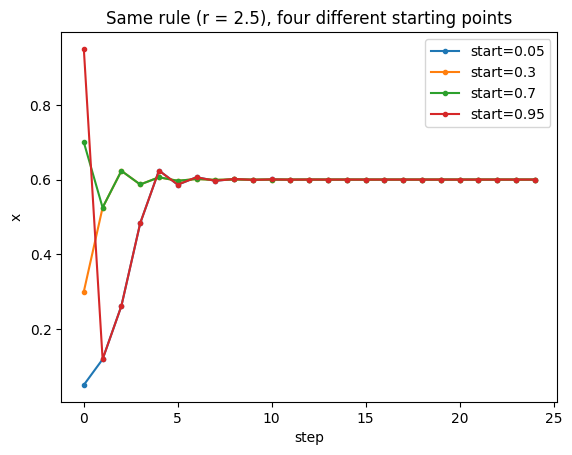

In [14]:
plt.figure()
for x0 in starts_take2:
    label = f"start={x0}"
    plt.plot(table_take2[(label, "x_t")].values, marker="o", markersize=3, label=label)
plt.title(f"Same rule (r = {r}), four different starting points")
plt.xlabel("step"); plt.ylabel("x")
plt.legend()
plt.show()


**AWE:** four wildly different starting points -- and they all end up in the exact same place.
The system doesn't care where it started. Whatever happened before doesn't matter -- only the rule
and where you are *right now* determine where you go next.

That settled-on value is called an **attractor** -- specifically, since it's a single fixed value,
a *fixed-point attractor*. And the fact that every starting point gets pulled into the same one is
what it means for a system to **forget its initial condition**.


---
## Take 3 — What if we turn the dial up a little?

`r` is the one number in our rule we haven't touched yet -- think of it as a dial. Right now it's
at 2.5. Let's turn it up to 3.2, change nothing else, and run the exact same repeated-feeding
experiment as Take 2.


Same `simulate` function as before, same style of plot -- only the value of `r` is different.


Same `x_t` / `x_next` pattern as Take 1 and Take 2's tables, just at a higher `r` and one trajectory instead of four.

In [15]:
r = 3.2
n_steps_take3 = 30
x_t_take3 = simulate(r, x0=0.3, n_steps=n_steps_take3)
x_next_take3 = logistic_step(x_t_take3, r)

table_take3 = pd.DataFrame({"x_t": x_t_take3, "x_next": x_next_take3})
table_take3.index.name = "step"
table_take3


,x_t,x_next
step,,
0,0.300000,0.672000
1,0.672000,0.705331
2,0.705331,0.665085
3,0.665085,0.712790
4,0.712790,0.655105
5,0.655105,0.723016
6,0.723016,0.640845
7,0.640845,0.736521
8,0.736521,0.620986


Same handoff as before -- each row's `x_next` matches the row below's `x_t`. But scan down far enough and, unlike Take 2's table, the numbers stop settling on one value and start alternating between two -- that's the split the picture below is about to make visible.

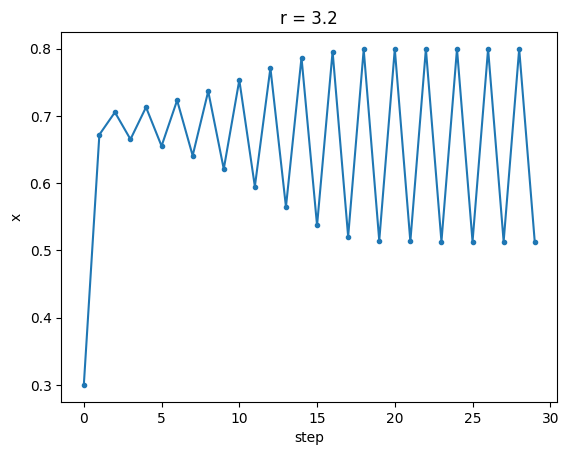

In [16]:
plt.figure()
plt.plot(table_take3["x_t"].values, marker="o", markersize=3)
plt.title(f"r = {r}")
plt.xlabel("step"); plt.ylabel("x")
plt.show()


**AWE:** it stopped settling on one value. Now it bounces forever between two values -- forever
visiting the same two numbers, back and forth, never landing on just one. We turned one dial by
0.7, and the system's entire long-run behavior changed in *kind*, not just in degree: one attractor
became two.

The point where that split happens, as we turn the dial, is called a **bifurcation** -- and the new
two-value pattern it settles into is called a *period-2 attractor*.


---
## A closer look — the cobweb diagram

Take 2 showed a fixed point settling; Take 3 showed a two-point loop -- both as plain time series.
There's a second, geometric way to watch the exact same thing happen, and it deserves its own
proper look rather than a quick aside: a **cobweb diagram**. Each step is really two moves: go up
or down to the curve (apply the rule), then straight across to the diagonal line (feed the result
back in as the next `x`). Tracing that staircase shows you exactly where a trajectory is heading,
geometrically.


Let's see it once, at the same `r = 2.5` from Take 2, to learn how to read it.


Same `x_t` / `x_next` table again, at the Take 2 settings (`r = 2.5`, start = 0.3) -- these are the exact numbers the staircase below is going to trace.

In [17]:
r = 2.5
x_t_cobweb = simulate(r, x0=0.3, n_steps=40)
x_next_cobweb = logistic_step(x_t_cobweb, r)

table_cobweb = pd.DataFrame({"x_t": x_t_cobweb, "x_next": x_next_cobweb})
table_cobweb.index.name = "step"
table_cobweb


,x_t,x_next
step,,
0,0.300000,0.525000
1,0.525000,0.623437
2,0.623437,0.586908
3,0.586908,0.606118
4,0.606118,0.596848
5,0.596848,0.601551
6,0.601551,0.599218
7,0.599218,0.600389
8,0.600389,0.599805


The cobweb diagram is just a geometric redraw of this same handoff: from `(x_t, x_t)` on the dashed diagonal, up or down to `(x_t, x_next)` on the curve, then across to the diagonal again at the new `x_t` -- repeat. Nothing in the picture below uses any number that isn't already sitting in this table.

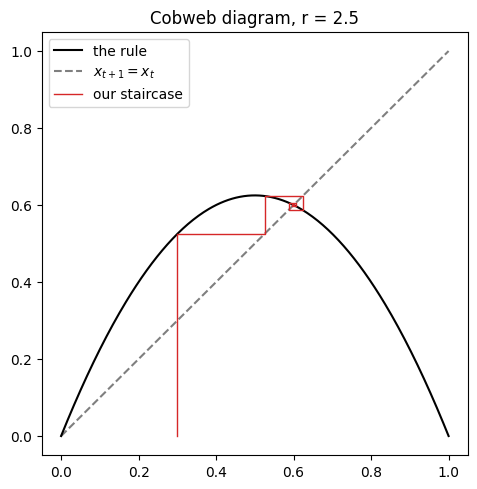

In [18]:
cx, cy = cobweb_path(r, x0=0.3, n_steps=40)

plt.figure(figsize=(5.5, 5.5))
xs = np.linspace(0, 1, 300)
plt.plot(xs, logistic_step(xs, r), "k", label="the rule")
plt.plot(xs, xs, "k--", alpha=0.5, label="$x_{t+1}=x_t$")
plt.plot(cx, cy, color="tab:red", linewidth=1, label="our staircase")
plt.title(f"Cobweb diagram, r = {r}")
plt.legend()
plt.show()


**Reading it:** the red staircase spirals inward and locks onto the single point where the curve
crosses the diagonal -- an **attractor**. Every starting point's staircase spirals into that same
crossing point, no matter where it begins.


Now let's add a second piece: instead of just eyeballing how many points the staircase settles
onto, let's count them automatically.


**No data table for this part.** The slider below regenerates its own `x_t` / `x_next` pairs every time you move it -- a table printed here would be stale the instant you touch the control. It's built from the exact same `simulate` / `cobweb_path` functions already tabulated above, just re-run live at whatever `r` and frame you pick.

### Now, watch the staircase get built, one step at a time

Same idea as before, but redrawn a faster way: instead of pre-rendering a whole animation up
front (which takes a few seconds to generate every time `r` changes), we'll redraw a single frame
live, on demand, only when something actually changes. Two separate controls: a slider that picks
`r`, and a play button that advances *only the frame counter* -- moving through one fixed `r`'s
staircase, one small step at a time.

**Nothing here can go wrong.** There's no setting to break, and playing with the slider or the
play button never touches anything else in this notebook -- feel free to drag, press, and re-press
as much as you like.


### Pseudocode — `draw_cobweb`

1. Read whatever `r` and `frame` the two controls are currently set to
2. Build the staircase up to that frame
3. Clear whatever was drawn last time, without any flicker
4. Redraw the curve, the diagonal, the staircase so far, and a dot marking the current point
5. Title the plot with `r`, how many iterations have completed, and how many attractor points
   `count_attractors` finds at this `r`


In [19]:
import ipywidgets as widgets
from IPython.display import display, clear_output

try:
    from google.colab import output as colab_output
    colab_output.enable_custom_widget_manager()
except ImportError:
    pass   # not running in Colab -- nothing extra needed

MAX_ITERATIONS = 40

play_button = widgets.Play(value=0, min=0, max=2 * MAX_ITERATIONS, step=1, interval=250)
r_selector = widgets.FloatSlider(
    value=3.20, min=2.5, max=3.99, step=0.01, description="r:",
    continuous_update=False, readout_format=".2f", layout=widgets.Layout(width="400px"),
)
plot_output = widgets.Output()

def draw_cobweb(*args):                                                # (1)
    r, frame = r_selector.value, play_button.value
    points, current_x, iteration = cobweb_points_up_to(r, frame)        # (2)
    n_attractors = count_attractors(r)
    attractor_label = f"{n_attractors} attractor point(s)" if n_attractors else "looks chaotic"

    with plot_output:
        clear_output(wait=True)                                         # (3)
        fig, ax = plt.subplots(figsize=(5.5, 5.5))                       # (4)
        xs = np.linspace(0, 1, 300)
        ax.plot(xs, logistic_step(xs, r), "k", label="the rule")
        ax.plot(xs, xs, "k--", alpha=0.4, label="$x_{t+1}=x_t$")
        if len(points) > 1:
            ax.plot(points[:, 0], points[:, 1], color="tab:red", linewidth=1)
        ax.scatter(points[-1, 0], points[-1, 1], color="tab:red", s=45, zorder=5)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title(f"r = {r:.2f}   n = {iteration}   |   {attractor_label}")   # (5)
        ax.legend(loc="upper left")
        plt.show()
        plt.close(fig)


Whenever `r` changes, restart the frame counter so the animation begins fresh from the new curve.
Then connect both controls, and draw the first frame.


In [20]:
def on_r_change(change):
    play_button.value = 0
    draw_cobweb()

play_button.observe(draw_cobweb, names="value")
r_selector.observe(on_r_change, names="value")

display(widgets.HBox([play_button, r_selector]), plot_output)
draw_cobweb()


Output()

**AWE:** move the slider to `3.2`, `3.5`, or `3.7`, then press play each time and watch the dot
travel -- up to the curve, across to the diagonal, up to the curve again. At `3.2` it settles into
retracing a 2-step loop forever; at `3.5`, a 4-step loop; past the chaotic threshold, no repeating
loop ever appears at all. That repeating loop *is* the attractor, now visible as a process instead
of a finished picture -- and this time, changing `r` updates instantly, without waiting for an
entire animation to pre-render.


**AWE:** slide `r` up slowly and watch both things happen together -- the staircase's shape
changes, and the attractor count printed in the title jumps: 1, then 2, then 4, then "no simple
cycle." That count *is* the bifurcation cascade from Take 3, now something you can page through by
hand, one `r` at a time -- right before Take 4 automates the same idea across thousands of `r`
values at once.


---
**📍 Welcome back.** Whether you tried three values or thirty, here's what to take with you into
Take 4.


---
## Take 4 — What if we keep turning that same dial, systematically?

Take 3 was one nudge, one result. This time, let's automate it: run that exact same
settle-and-record experiment at thousands of different `r` values in a row, sweeping smoothly from
2.5 up to 4.0.


Let's run it across the full range and plot every `r` against everywhere it ends up settling.


Here's the data behind this picture: one row per `(r, settled x)` pair from `sweep()`. At 2000 r-values x 150 recorded points each, it's a big table -- pandas will only show you the first and last few rows, which is enough to see the shape of it.

In [21]:
bif_r, bif_x = sweep(r_min=2.5, r_max=4.0, n_r=2000)
table_take4 = pd.DataFrame({"r": bif_r, "x": bif_x})
table_take4


,r,x
0,2.500000,0.600000
1,2.500750,0.600120
2,2.501501,0.600240
3,2.502251,0.600360
4,2.503002,0.600480
...,...,...
299995,3.996998,0.015453
299996,3.997749,0.050907
299997,3.998499,0.455642
299998,3.999250,0.292472


Each row pairs one dial setting with one point it lands on, long-run. Near the top (`r` close to 2.5) every row for a given `r` shares almost the same `x` -- one settled value, 150 times over. Jump to rows with `r` past about 3.57 and the same `r` now shows up next to several different `x` values -- that row-level scatter is exactly what turns into the cascade in the picture below.

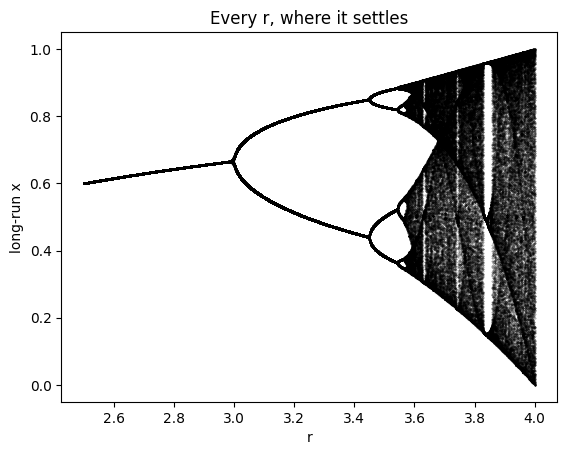

In [22]:
plt.figure()
plt.scatter(table_take4["r"], table_take4["x"], s=0.15, alpha=0.4, color="black")
plt.title("Every r, where it settles")
plt.xlabel("r"); plt.ylabel("long-run x")
plt.show()


**AWE:** one settling point becomes two, becomes four, becomes eight -- faster and faster --
until it dissolves into what looks like static, with a few strange clear gaps still visible inside
the static. Nobody told the system to do this. It's a direct, mechanical consequence of turning one
dial continuously on one unchanged, one-line rule. No randomness anywhere in this code -- every
pixel of this picture is fully determined by the rule alone.

This whole picture is called a **bifurcation diagram**, and the region where it turns to static is
called **chaos**.


---
## Take 5 — What if we barely change where we start, instead of the rule?

Different kind of change this time: leave `r` fixed, and instead nudge the *starting point* by an
almost unimaginably small amount -- one hundred-millionth.


Let's compare it at two different `r` values side by side: one we already know settles quietly
(`r = 2.9`), and one deep in the chaotic region from Take 4 (`r = 3.9`).


And here's the data for both panels, side by side -- two starting points, at two different `r` values. `start A` and `start B` begin only `1e-8` apart.

In [23]:
table_take5 = pd.DataFrame()
for r_val in [2.9, 3.9]:
    x1, x2 = two_starts(r=r_val, x0=0.2, epsilon=1e-8, n_steps=60)
    table_take5[f"r={r_val}, start A"] = x1
    table_take5[f"r={r_val}, start B"] = x2
table_take5.index.name = "step"
table_take5


,"r=2.9, start A","r=2.9, start B","r=3.9, start A","r=3.9, start B"
step,,,,
0,0.200000,0.200000,0.200000,0.200000
1,0.464000,0.464000,0.624000,0.624000
2,0.721242,0.721242,0.915034,0.915034
3,0.583051,0.583051,0.303214,0.303214
4,0.704997,0.704997,0.823973,0.823973
5,0.603131,0.603131,0.565661,0.565661
6,0.694156,0.694156,0.958185,0.958186
7,0.615680,0.615680,0.156258,0.156257
8,0.686192,0.686192,0.514181,0.514180


Compare the two `r=2.9` columns row by row and they barely drift apart the whole way down. Do the same for the two `r=3.9` columns and watch how quickly the two numbers stop matching -- that split is what the right-hand panel below is showing you as a picture.

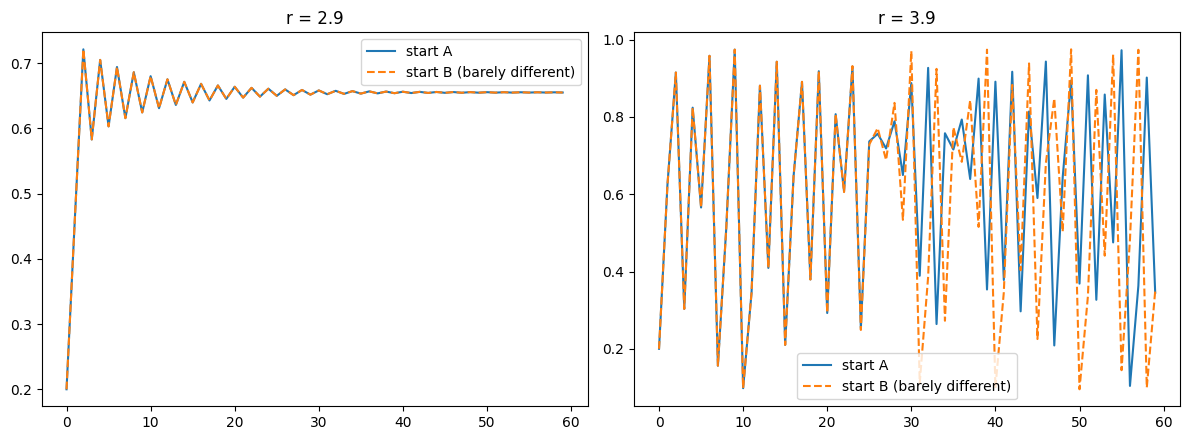

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for r_val, ax in zip([2.9, 3.9], axes):
    ax.plot(table_take5[f"r={r_val}, start A"].values, label="start A")
    ax.plot(table_take5[f"r={r_val}, start B"].values, linestyle="--", label="start B (barely different)")
    ax.set_title(f"r = {r_val}")
    ax.legend()

plt.tight_layout()
plt.show()


**AWE:** at `r = 2.9`, the two lines are indistinguishable -- the tiny difference we started with
just vanished, the same forgetting we saw back in Take 2. But at `r = 3.9`, they track together for
a while, and then split completely apart. Same rule, virtually the same starting point, totally
different outcome.

This is called **sensitivity to initial conditions**, and it's the defining signature of chaos:
instead of forgetting small differences, the system **remembers and amplifies** them.


---
## Take 6 — What if we put a number on how fast that split happens?

Take 5 showed us divergence by eye, at two specific `r` values. Let's turn that into a single
measurable number, computed directly from the rule itself.


Now let's sweep this across the exact same range of `r` we used for Take 4's bifurcation diagram,
and plot the two, one above the other, so we can line them up directly.


Here's the divergence-speed number for every `r` in the sweep, before we plot it against Take 4's picture.

In [25]:
r_sweep = np.linspace(2.5, 4.0, 400)
table_take6 = pd.DataFrame({"r": r_sweep, "divergence_speed": [divergence_speed(r) for r in r_sweep]})
table_take6


,r,divergence_speed
0,2.500000,-0.693147
1,2.503759,-0.685657
2,2.507519,-0.678222
3,2.511278,-0.670841
4,2.515038,-0.663515
...,...,...
395,3.984962,0.624539
396,3.988722,0.640460
397,3.992481,0.641071
398,3.996241,0.662374


One row per `r`, next to the single number computed for it. Scan down `divergence_speed` and find the row where it crosses from negative to positive -- that's the same crossing point the two-panel picture below lines up directly against the bifurcation diagram.

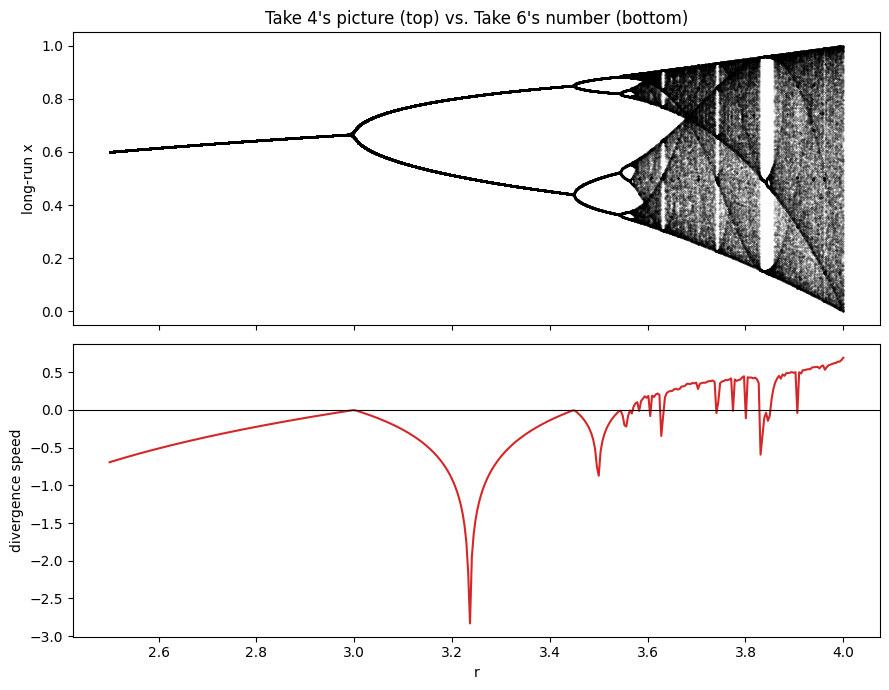

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].scatter(table_take4["r"], table_take4["x"], s=0.1, alpha=0.3, color="black")
axes[0].set_ylabel("long-run x")
axes[0].set_title("Take 4's picture (top) vs. Take 6's number (bottom)")

axes[1].plot(table_take6["r"], table_take6["divergence_speed"], color="tab:red")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("divergence speed")
axes[1].set_xlabel("r")
plt.tight_layout()
plt.show()


**AWE:** this one number goes negative exactly where Take 4's picture shows one settled value, and
crosses zero exactly where the picture splits. One quantity, computed from nothing but the rule
itself, tells you *in advance* whether tiny errors will shrink or explode -- without ever having to
run the two-trajectory experiment from Take 5 at all.

This number is called the **Lyapunov exponent** ($\lambda$). Negative means predictable, positive
means chaotic, and zero marks the exact boundary -- a bifurcation point, same as Take 3.

**Two concrete numbers worth sitting with, from this same computation:**
- At `r = 2.9` ($\lambda < 0$): a small error shrinks by about 10% every step -- cut in half within
  6 steps.
- At `r = 3.7` ($\lambda > 0$): a small error *grows* by about 43% every step -- doubled in under 2
  steps, and ten times larger within 6 steps.

Past that threshold, no amount of better data or a fancier model buys you longer-range prediction
-- it's mathematically, not practically, out of reach. The honest move shifts from *predict further
ahead* to *react faster*.


---
## What we actually did, across six takes

| Take | The one thing we changed | What it revealed |
|---|---|---|
| 1 | nothing -- just looked at the rule | a plain curve |
| 2 | fed the output back in, repeatedly | the system **forgets** where it started |
| 3 | nudged `r` up a little | one settled value became two |
| 4 | swept `r` across a whole range | the full cascade: 1 -> 2 -> 4 -> 8 -> chaos |
| 5 | nudged the *starting point*, not `r` | the system **remembers and amplifies** tiny differences |
| 6 | measured Take 5's effect directly | one number predicts predictability itself |

Every single Take reused the same one-line rule from Take 1. Nothing about the rule ever changed
-- only how we *used* it. That's the whole lesson: complexity, unpredictability, sudden regime
change -- none of it required more variables, more agents, or more randomness. It required
**simulating and watching**, one change at a time.


**One thing worth sitting with, now that we're done.** Everything in this notebook came from one
line of arithmetic -- no agents, no other people, no social system of any kind. And yet turning one
dial was enough to produce forgetting, splitting, and full unpredictability, without adding a
single new variable. That's not a trick specific to this one equation. It's a demonstration of
something computing made possible that Weaver and Simon, writing before simulation was cheap, could
describe but not show you directly: sometimes the only way to find out what a system does is to
build it and run it.

That's the frame to carry into Session 2. Kollman and Page take these same underlying questions
about complexity and move them onto human ground -- real people, interacting, in real political and
social settings. What that actually looks like is for the reading itself to tell you, not this
notebook. What this notebook can tell you is why building and running a model, rather than only
reasoning about it on paper, might be worth the trouble.


One more thing worth naming: every one of those six Takes called functions from the same eight-
function Toolbox defined once at the top. No Take needed its own new code -- only a new way of
calling what was already there.
